In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Compute therorical profiles
x=np.linspace(0.1,100000,1000000)
yp=x

#Laminar
up=yp
#Low-law
up1=(1.0/0.41)*np.log(yp)+5.0


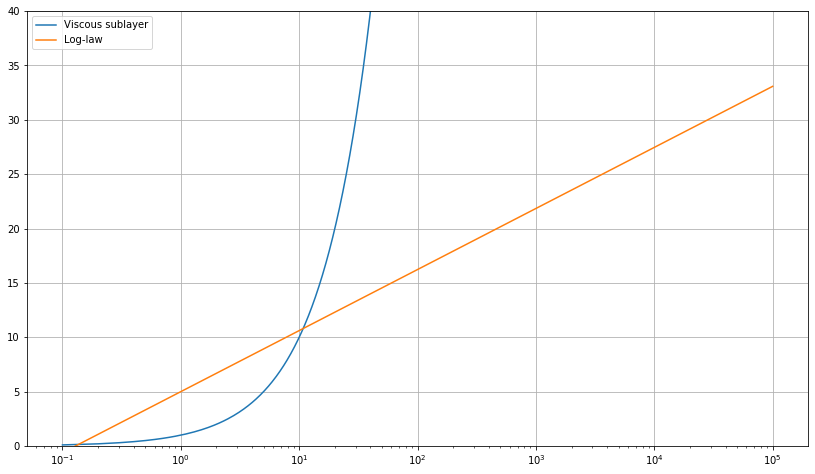

In [4]:
#Plot law of wall

#Plot profiles
plt.figure(figsize=(14, 8))

plt.plot(yp,up,label='Viscous sublayer')
plt.plot(yp,up1,label='Log-law')

plt.xscale('log')
#plt.xlim(0.1,100000)
plt.ylim(0,40)

plt.grid()
plt.legend(loc=2)


In [5]:
#load cfl3d data at x=1.90334
data = np.loadtxt("CFL3D_X2.txt",skiprows=2)

#Antilogarithm of input data
al=10**data[:,0]

In [6]:
#Load openfoam data
data1 = np.loadtxt("../postProcessing/sampleDict/2000/profile0_U_wallShearStress.xy",skiprows=0)
data2 = np.loadtxt("../postProcessing/sampleDict/2000/profile1_U_wallShearStress.xy",skiprows=0)

In [7]:
#interpolate data
from scipy import interpolate
#fint=interpolate.interp1d(data2[:,0],data2[:,4],kind='linear',bounds_error=False)
fint=interpolate.interp1d(data2[:,0],data2[:,4],kind='linear')

#interpolation function of each ws component
fintwsx=interpolate.interp1d(data2[:,0],data2[:,4],kind='linear')
fintwsy=interpolate.interp1d(data2[:,0],data2[:,5],kind='linear')
fintwsz=interpolate.interp1d(data2[:,0],data2[:,6],kind='linear')

#find value at a given point
#fint(xloc)

In [8]:
#Where to sample
xloc=1.90334   

#Input values
U = 1
nu = 2.0e-07
rho = 1.0

In [9]:
#Compute wall shear stress magnitude and velocity magnitude
#Shear stress units is in pascal must multiply by density in incompressible flows

ws = np.sqrt(data1[:,4]**2 + data1[:,5]**2 + data1[:,6]**2)
um = np.sqrt(data1[:,1]**2 + data1[:,2]**2 + data1[:,3]**2)

#wsm=0.0012264945506493506
#wsm=0.0020894076746453545

#Only use intermpolated data of x component
#wsm=np.abs(fint(xloc))

#Use interpolated data of all component
wsm = np.sqrt(np.abs(fintwsx(xloc))**2+np.abs(fintwsy(xloc))**2+np.abs(fintwsz(xloc))**2)

utau=np.sqrt(wsm/rho)
ypn=utau*data1[:,0]/nu
upn=um/utau

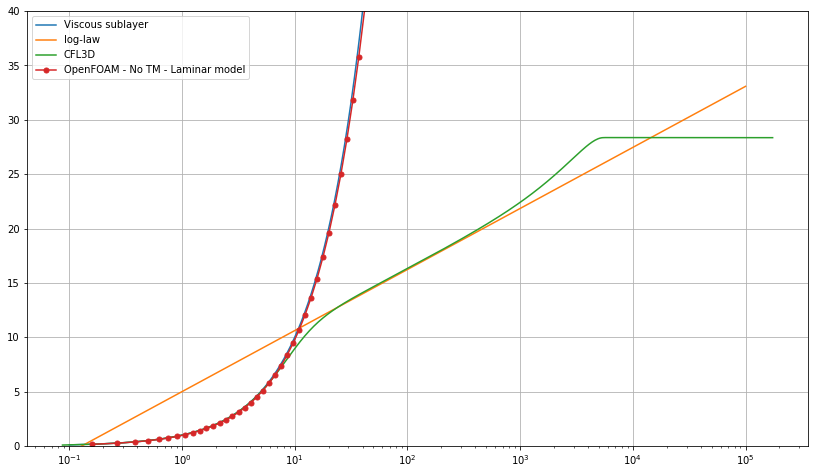

In [10]:
#Plot profiles

plt.figure(figsize=(14, 8))

#Correlations
plt.plot(yp,up,label='Viscous sublayer')
plt.plot(yp,up1,label='log-law')

#cfl3d
#plt.plot(ypn,upn,'-o',ms=6)
plt.plot(al,data[:,1],'-',label='CFL3D')

#OpenFOAM
#plt.plot(ypn[0:],upn[0:],'-o',label='OpenFOAM')
plt.plot(ypn[1:],upn[1:],'-o', ms=5, label='OpenFOAM - No TM - Laminar model')
#plt.plot(ypn,upn,'-o',ms=4,label='OpenFOAM')

plt.xscale('log')
#plt.xlim(0.1,100000)
plt.ylim(0,40)

plt.grid()
plt.legend(loc=2)

#plt.savefig("fig.png")

In [11]:
#Compute wall shear stress magnitude and velocity magnitude
#Shear stress units is in pascal must multiply by density in incompressible flows

ws2 = np.sqrt(data2[:,4]**2 + data2[:,5]**2 + data2[:,6]**2)
#ws2 = nu*np.sqrt(data2[:,4]**2 + data2[:,5]**2 + data2[:,6]**2)
#ws2 = np.sqrt(data2[:,4]**2)

In [12]:
#Compute plate reaynolds X and friction coefficient

x_plate=np.linspace(0.00001,2,1000)
re_x=x_plate*U/nu
small=1e-12
#cf_re=0.0592/(re_x+1*small)**(0.2)
cf_re=0.0592/(re_x)**(0.2)

cf_re2=0.664/(re_x)**(0.5)

cf_of=ws2/(0.5*rho*U**2)
#cf_of=2*ws2

In [13]:
#Read data extracted from paraview

#mesh1 from blockMesh
data3 = np.loadtxt("./ws_m1.csv",skiprows=1,delimiter=',')
#mesh2 from NASA plot3d
#data3 = np.loadtxt("./ws_m2.csv",skiprows=1,delimiter=',')

#Compute cf using paraview data

#ws_pv=np.sqrt(data3[:,1]**2.+data3[:,2]**2.+data3[:,3]**2.)
#l_pv=data3[:,9]
ws_pv=np.sqrt(data3[:,2]**2.+data3[:,3]**2.+data3[:,4]**2.)
l_pv=data3[:,8]
cf_pv=ws_pv/(0.5*rho*U**2.)

In [14]:
#read data from CFL3D and FUN3D
cf1 = np.loadtxt("./CFL3D.txt",skiprows=2)
cf2 = np.loadtxt("./FUN3D.txt",skiprows=2)

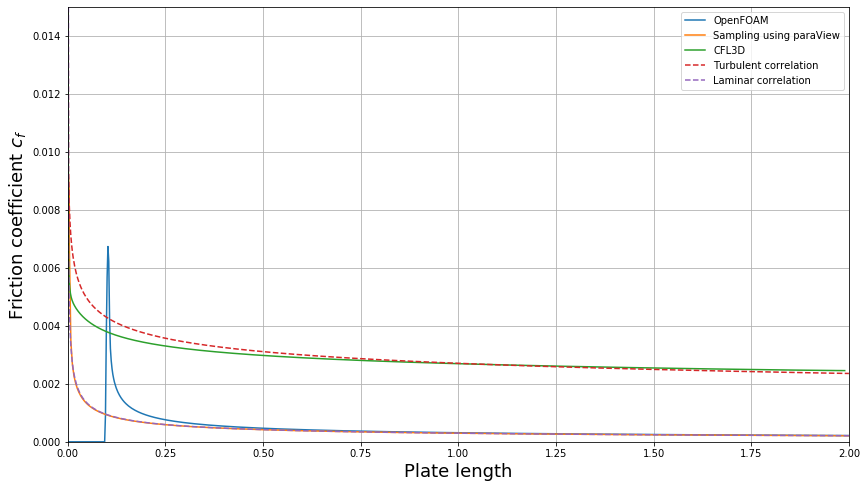

In [15]:
#Plot data

plt.figure(figsize=(14, 8))

plt.plot(data2[:,0],cf_of,'-',label='OpenFOAM')

plt.plot(l_pv,cf_pv,label='Sampling using paraView')

plt.plot(cf1[:,0],cf1[:,1],'-',label='CFL3D')

#plt.plot(cf2[:,0],cf2[:,1],'-',label='FUN3D')

plt.plot(x_plate,cf_re,'--',label='Turbulent correlation')

plt.plot(x_plate,cf_re2,'--',label='Laminar correlation')

plt.xlabel('Plate length',fontsize=18)
plt.ylabel('Friction coefficient $c_f$',fontsize=18)

plt.xlim(0,2)
plt.ylim(0,0.015)
plt.grid()

plt.legend(loc=0)

#plt.savefig("fig.png")